# R-Score Band Analysis

Divide applicants into five equal-sized bands by R-score. Compare historical scholarship grant rates for center and remote applicants in each band.

Historical grant rate (%) by R-score band:
region_group  center  remote
r_band                      
1 lowest         0.7     0.1
2               10.9     2.7
3               37.5    12.8
4               79.6    50.5
5 highest       98.1    91.4


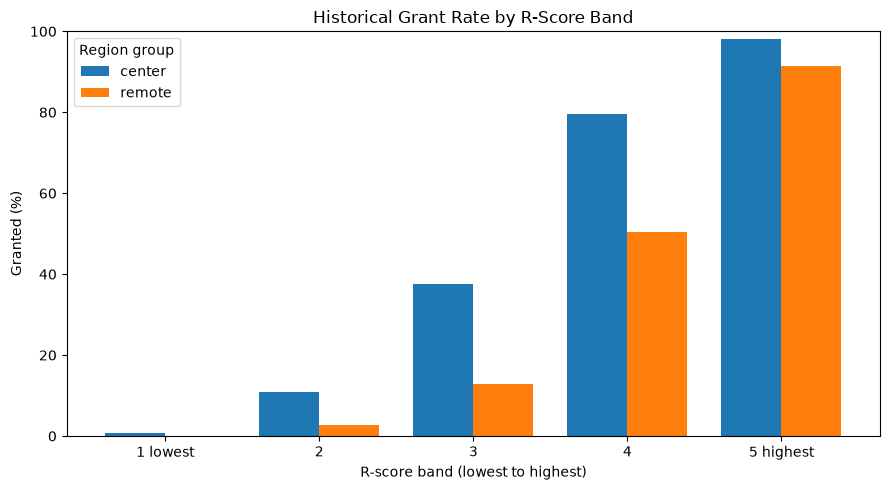

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/fairness_and_bias_analysis/past_committee_decisions/r_band_analysis.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "Analysis" / "fairness_and_bias_analysis" / "past_committee_decisions"
analysis_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(repository_root / raw_relative_path)
remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
df["region_group"] = df["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

band_labels = ["1 lowest", "2", "3", "4", "5 highest"]
df["r_band"] = pd.qcut(df["cote_r_equivalent"], q=5, labels=band_labels)

table = (
    df.pivot_table(
        index="r_band",
        columns="region_group",
        values="decision_octroi",
        aggfunc="mean",
        observed=True,
    )
    .reindex(columns=["center", "remote"])
    .mul(100)
)

print("Historical grant rate (%) by R-score band:")
print(table.round(1).to_string())

ax = table.plot(kind="bar", figsize=(9, 5), width=0.78)
ax.set_title("Historical Grant Rate by R-Score Band")
ax.set_xlabel("R-score band (lowest to highest)")
ax.set_ylabel("Granted (%)")
ax.set_ylim(0, 100)
ax.legend(title="Region group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "r_band_analysis.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path}")